# 파이토치

In [3]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:
import torch

def test_installation():
    print('PyTorch Version:{torch.__version__}')
    if torch.cuda.is_available():
        print('CUDA is available. GPU를 사용합니다.')
        print(f'사용 가능한 GPU 개수: {torch.cuda.device_count()}')
        print(f'현재 GPU 이름: {torch.cuda.get_device_name(0)}')
    else:
        print('CUDA를 사용할 수 없습니다. CPU 모드로 실행합니다.')

test_installation()

PyTorch Version:{torch.__version__}
CUDA is available. GPU를 사용합니다.
사용 가능한 GPU 개수: 1
현재 GPU 이름: NVIDIA GeForce RTX 5060 Laptop GPU


In [5]:
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

a_cpu = torch.randn(4000, 4000)
b_cpu = torch.randn(4000, 4000)

start_time = time.time()
c_cpu = torch.matmul(a_cpu, b_cpu)
cpu_time = time.time() - start_time
print(f'CPU 연산 시간: {cpu_time:.4f}초')

if torch.cuda.is_available():
    a_gpu = a_cpu.to(device)
    b_gpu = b_cpu.to(device)

    start_time = time.time()
    c_gpu = torch.matmul(a_gpu, b_gpu)
    torch.cuda.synchronize()   # GPU 연산 완료 대기
    gpu_time = time.time() - start_time
    print(f'속도 향상: {cpu_time/gpu_time:.1f}배 빨라짐!')

CPU 연산 시간: 0.1620초
속도 향상: 2.0배 빨라짐!


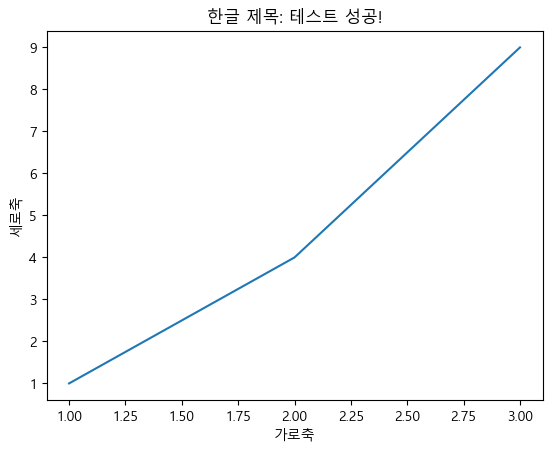

In [6]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['font.family'] = 'Malgun Gothic'
rcParams['axes.unicode_minus'] = False

plt.figure()
plt.title("한글 제목: 테스트 성공!")
plt.plot([1, 2, 3], [1, 4, 9])
plt.xlabel("가로축")
plt.ylabel("세로축")
plt.show()

# 신경망

In [7]:
# 단층 퍼셉트론

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns


In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

print(torch.__version__)

cuda
2.11.0+cu128


In [9]:
torch.manual_seed(42)
np.random.seed(42)

In [10]:
def perceptron_and(x1, x2):
    w = torch.tensor([0.5, 0.5])
    b = torch.tensor(-0.7)
    x = torch.tensor([x1, x2], dtype = torch.float32)
    output = torch.dot(w, x) + b
    return 1 if output >= 0 else 0

print(perceptron_and(0, 0))
print(perceptron_and(0, 1))
print(perceptron_and(1, 0))
print(perceptron_and(1, 1))


0
0
0
1


In [11]:
class SimpleNN(nn.Module):
    def __init__(self): # 층 정의
        super(SimpleNN, self).__init__()
        # nn.Linear(입력차원, 출력차원)
        self.fc1 = nn.Linear(2,3) #층 1 입력 2 -> 출력 3 (은닉층)
        self.fc2 = nn.Linear(3,1) #층 2 입력 3 -> 출력 1 (출력층)

    def forward(self, x): # 계산흐름
        x = torch.relu(self.fc1(x)) # 층1 통과 -> relu (음수제거)
        x = torch.sigmoid(self.fc2(x)) # 층2 통과 -> sigmoid (0~1 확률)
        return x

model = SimpleNN()
sample_input = torch.tensor([1.0, 2.0])
output = model(sample_input)
print(output)

tensor([0.6693], grad_fn=<SigmoidBackward0>)


In [12]:
class SimpleNN_Full(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):   # 인자 3개
        super(SimpleNN_Full, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

model = SimpleNN_Full(input_size=10, hidden_size=20, output_size=1)
print(model)

for param in model.parameters():
    print(param.shape)

SimpleNN_Full(
  (fc1): Linear(in_features=10, out_features=20, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=20, out_features=1, bias=True)
)
torch.Size([20, 10])
torch.Size([20])
torch.Size([1, 20])
torch.Size([1])


In [13]:
X_train = torch.randn(100, 10)
y_train = torch.randn(100, 1)
datasets = TensorDataset(X_train, y_train)

dataloader = DataLoader(datasets, batch_size = 32, shuffle = True) # train 일떄는 셔플 true test 일때는 false

In [14]:
# loss 계산 / optimizer 설정 (= 모델이 틀린걸 보고 가중치를 조금씩 고치는 과정임/ 경사하강법으로 개선)

criterion = nn.MSELoss() #손실함수 (숫자예측용)
optimizer = optim.Adam(model.parameters(), lr = 0.001)

for epoch in range(10):
    for batch in dataloader:
        inputs, targets = batch
        optimizer.zero_grad() #기울기 초기화 / 그전에 계산된 기울기 값이 남아있을수 있으므로 초기화
        outputs = model(inputs) # 예측
        loss = criterion(outputs, targets) # loss(손실계산) = criterion(예측(outputs), 정답(targets))
        loss.backward() # loss 기준으로 기울기 계산.
        optimizer.step() # 가중치 업데이트
    print(epoch + 1, loss.item())
    


1 0.9306035041809082
2 1.979332447052002
3 0.524667501449585
4 0.9314338564872742
5 2.472566843032837
6 1.977538824081421
7 2.6563892364501953
8 1.100563645362854
9 1.5428667068481445
10 0.08924788981676102


In [15]:
#모델 저장
torch.save(model.state_dict(), "model.pth")
model = SimpleNN_Full(input_size = 10, hidden_size = 20, output_size = 1)
model.load_state_dict(torch.load("model.pth"))


<All keys matched successfully>

In [16]:
# 학습률을 10분의 1로 줄이는 방법

def check_nan_loss(loss, optimizer):
    if torch.isnan(loss).any():
        print("Loss nan가 포함되어 있음")

        for param_group in optimizer.param_groups:
            param_group["lr"] *= 0.1 # Learning rate를 0.1배로 줄임.
        return True # nan이 포함되있으면 true 반환
    return False # nan이 없으면 false 반환

sample_loss = torch.tensor(float("nan"))
nan_detected = check_nan_loss(sample_loss, optimizer)
print(nan_detected)


Loss nan가 포함되어 있음
True


In [17]:
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])


In [18]:
## MNIST 데이터셋 불러오기

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = torchvision.datasets.MNIST(
    root = "./data",
    train = True,
    transform = transform,
    download = True
)

test_dataset = torchvision.datasets.MNIST(
    root = "./data",
    train = False,
    transform = transform,
    download = True
)

In [19]:
train_loader = DataLoader(dataset = train_dataset, batch_size = 64, shuffle = True)

test_loader = DataLoader(dataset = test_dataset, batch_size = 1000, shuffle = False)

print(len(train_loader))
print(len(test_loader))

938
10


In [20]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)


    def forward(self, x):
        x = x.view(-1, 28 * 28) # 2차원으로 변환
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

    

In [21]:
# 손실함수와 옵티마이저

model = MLP().to(device)

criterion = nn.CrossEntropyLoss() # 다중분류용 손실함수

optimizer = optim.Adam(model.parameters(), lr = 0.001) # Adam optimizer

In [22]:
# 모델 학습

for epoch in range(10):
    model.train() # 학습모드
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device) # GPU로 데이터 이동
        optimizer.zero_grad() # 기울기 초기화
        output = model(data) # 모델에 데이터 넣어서 예측
        loss = criterion(output, target) # 손실함수 계산
        loss.backward() # 기울기 계산
        optimizer.step() # 가중치 업데이트
    print(epoch + 1, loss.item())

1 0.25291579961776733
2 0.2146015167236328
3 0.0859103798866272
4 0.020982526242733
5 0.02018461748957634
6 0.0019541585352271795
7 0.00017118958930950612
8 0.008578936569392681
9 0.06651891767978668
10 0.005282195284962654


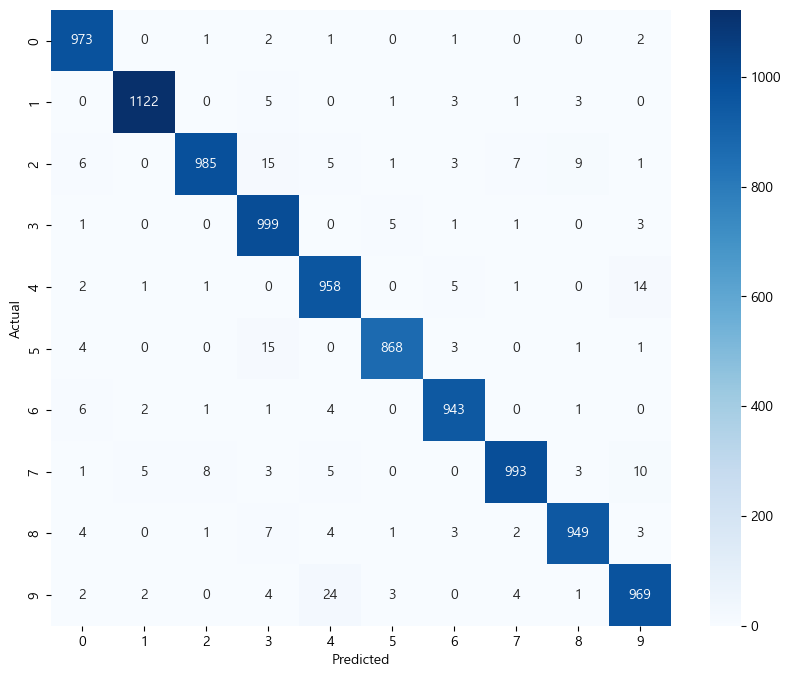

In [23]:
model.eval() # 평가모드 / 혼동행렬
all_targets = []
all_pred = []

with torch.no_grad(): # 평가모드에서는 기울기 계산 필요없음
    for data, target in test_loader:
        data, target = data.to(device), target.to(device) # GPU로 데이터 이동
        output = model(data) # 모델에 데이터 넣어서 예측
        _, predicted = torch.max(output.data, 1) # 예측값 중 가장 큰 값의 인덱스
        all_targets.extend(target.cpu().numpy()) # 정답값을 리스트에 추가 넘파이로 변환 후 CPU로 이동
        all_pred.extend(predicted.cpu().numpy()) # 예측값을 리스트에 추가 넘파이로 변환 후 CPU로 이동

# 혼동행렬 타켓과 프리드를 넘파이 배열로 변환
targets = np.array(all_targets)
preds = np.array(all_pred)

cm_mnist = confusion_matrix(targets, preds)
plt.figure(figsize = (10, 8))
sns.heatmap(
    cm_mnist, 
    annot = True, 
    fmt = "d", 
    cmap = "Blues", 
    xticklabels = range(10), 
    yticklabels = range(10)
    )
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

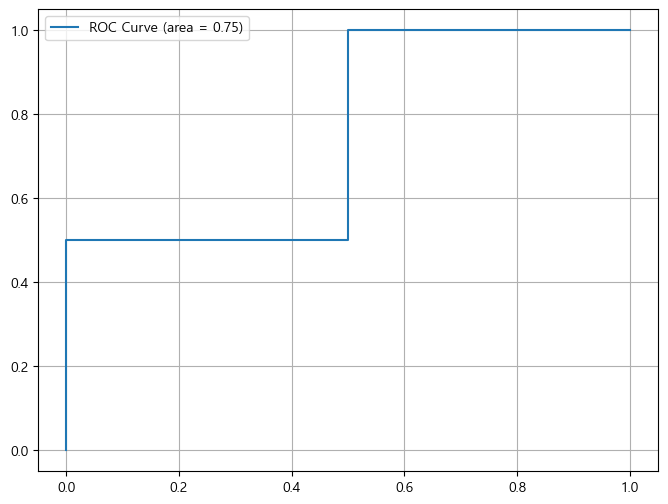

In [24]:
y_scores = np.array([0.1, 0.4, 0.35, 0.8])
y_test = np.array([0, 0, 1, 1])

fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize = (8, 6))
plt.plot(fpr, tpr, label = f"ROC Curve (area = {roc_auc:.2f})")
plt.legend()
plt.grid(True)
plt.show()

In [25]:
# from torch.optim.lr_scheduler import ReduceLROnPlateau

# scheduler = ReduceLROnPlateau(optimizer, mode = "min", patience = 3, factor = 0.1)
# for epoch in range(50):
#     # 추후에는 train_loss를 validation loss로 바꿔야함(하단)
#     ## train_one_epoch(model, train_loader, optimizer, criterion) # train loss 계산
#     ## val_loss = evaluate(model, val_loader) # validation loss 계산(하단에 train_loss 대신)
#     ## scheduler.step(val_loss) # validation loss를 기준으로 학습률 조정
#     train_loss = 0.2 * (50 - epoch) # 예시로 train_loss를 감소시키는 값으로 설정
#     scheduler.step(train_loss) # train_loss를 기준으로 학습률 조정


# 배치정규화

In [26]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 28 * 28) # 2차원으로 변환
        x = F.relu(self.bn1(self.fc1(x)))
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.fc3(x)
        return x

# dropout - 과적합을 줄일수 있음.

In [27]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.dropout1 = nn.Dropout(0.5) # 50% 날림.(일부만 가지고 학습한다는의미)
        # self.bn1 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 64)
        self.dropout2 = nn.Dropout(0.5) # 50% 날림.(일부만 가지고 학습한다는의미)
        # self.bn2 = nn.BatchNorm1d(64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 28 * 28) # 2차원으로 변환
        x = F.relu(self.dropout1(self.fc1(x)))
        x = F.relu(self.dropout2(self.fc2(x)))
        x = self.fc3(x)
        return x

# 딥러닝 모델 구축 
## 모델학습과정 이해 (09.02)

In [28]:
def pizza_price_model(size):
    weight = 2
    bias = 3
    price = weight * size + bias
    return price

size = 5
predicted_price = pizza_price_model(size)
print(predicted_price)

13


# 순전파 x들어가면 y 나옴

In [30]:
import torch

def foward_pass(x, w, b):
    z = torch.mm(x, w) + b
    output = torch.relu(z)
    return output

x = torch.tensor(
    [[1.0, 2.0], 
    [3.0, 4.0]]
    )
w = torch.tensor(
    [[0.5, -0.5], 
    [1.0, 1.0]]
    )
b = torch.tensor(
    [[1.0, 1.0]]
)

output = foward_pass(x, w, b)
print(output)

tensor([[3.5000, 2.5000],
        [6.5000, 3.5000]])


# 손실계산

In [32]:
import torch
import torch.nn as nn

x = torch.tensor(
    [[1.0],[2.0],[3.0],[4.0]]
)
y_true = 2 * x + 1

model_output = torch.tensor(
    [[2.5], [3.5], [4.5], [5.5]]
)
criterion = nn.MSELoss()

loss = criterion(model_output, y_true) # 순서 꼭 기억하기 (예측값, 정답값)
print(loss)

tensor(5.2500)


In [34]:
actual_price = 11
predicted_price = 13

error = predicted_price - actual_price

print(error)

weight = 2
bias = 3
learning_rate = 0.01
weight = weight - learning_rate * error * size
bias = bias - learning_rate * error

price = weight * size + bias
print(price)

2
12.48


# 역전파 

In [ ]:
import torch

# Input
x = torch.tensor(2.0, requires_grad = True)

# 순전파(forward)
y = x ** 2 + 3 * x + 4

# 역전파(backward)
y.backward()

print(x.grad) # 결과값은 x에 대한 기울기

tensor(7.)


In [ ]:
import torch

x = torch.tensor([
    [1.0, 2.0], 
    [3.0, 4.0]], 
    requires_grad = True
    )
y = (x ** 2).sum() #백터값이 들어가면 .sum() 들어가야함

y.backward()
print(x.grad)

tensor([[2., 4.],
        [6., 8.]])


# 선형회귀

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

class LinearRegressionModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(LinearRegressionModel, self).__init__()
        self.linear = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        return self.linear(x)


x = torch.tensor([[1.0],[2.0],[3.0],[4.0]]) # input
y_true = 2 * x + 1 # y_true값

model = LinearRegressionModel(1,1) # 입력1개 출력 1개
criterion = nn.MSELoss() # 로스계산
optimizer = optim.SGD(model.parameters(), lr = 0.01)

for epoch in range(100):
    optimizer.zero_grad()
    pred = model(x) # 순전파
    loss = criterion(pred, y_true) # 로스계산
    loss.backward() # 역전파
    optimizer.step() # 바뀐 웨이트와 바뀐 바이어스에 옵티마이저에 들어감.(적용된 파라미터 적용)
    if (epoch + 1) % 20 == 0:
        print(epoch + 1, loss.item())

20 0.13424542546272278
40 0.06555646657943726
60 0.05811125785112381
80 0.051543332636356354
100 0.045717742294073105


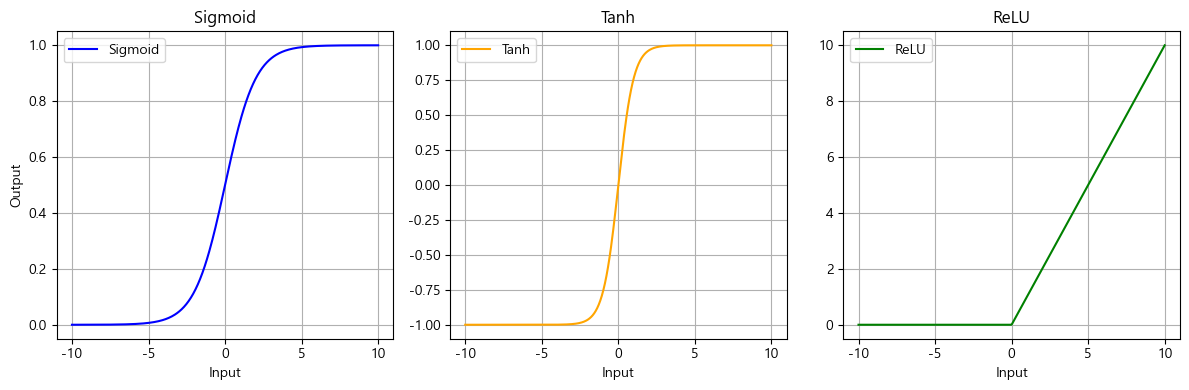

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 400)

def sigmoid(x): # 이진분류떄 씀.
    return 1 / (1 + np.exp(-x))

def tanh(x): # 값 그대로 리턴
    return np.tanh(x)

def relu(x): # x 가 음수가 들어오면 모든음수는 0 리턴
    return np.maximum(0, x)


y_sigmoid = sigmoid(x)
y_tanh = tanh(x)
y_relu = relu(x)

plt.figure(figsize=(12, 4))

# 1) Sigmoid
plt.subplot(1, 3, 1)
plt.plot(x, y_sigmoid, label='Sigmoid', color='blue')
plt.xlabel('Input')
plt.ylabel('Output')
plt.title('Sigmoid')
plt.grid(True)
plt.legend()

# 2) Tanh
plt.subplot(1, 3, 2)
plt.plot(x, y_tanh, label='Tanh', color='orange')
plt.xlabel('Input')
plt.title('Tanh')
plt.grid(True)
plt.legend()

# 3) ReLU # x양수면 한없이 무한대로 감.
plt.subplot(1, 3, 3)
plt.plot(x, y_relu, label='ReLU', color='green')
plt.xlabel('Input')
plt.title('ReLU')
plt.grid(True)
plt.legend()

# 서브플롯 간 여백 조정
plt.tight_layout()

plt.show()


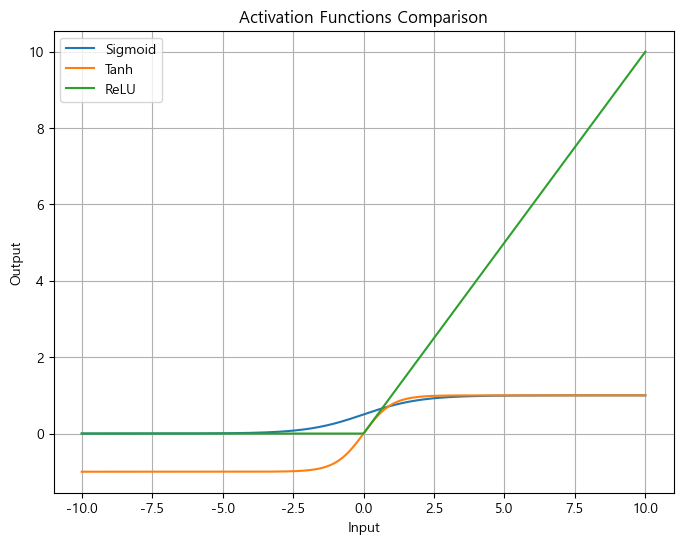

In [42]:
plt.figure(figsize=(8, 6))
plt.plot(x, y_sigmoid, label='Sigmoid')
plt.plot(x, y_tanh, label='Tanh')
plt.plot(x, y_relu, label='ReLU')
plt.xlabel('Input')
plt.ylabel('Output')
plt.title('Activation Functions Comparison')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# 렐루 - 0 또는 무한대
# 시그모이드 - 0에서 1 사이의 값
# 하이퍼탄젠트 - 수렴하는 값.

# 전체과정

In [44]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root = "./data", train = True, download = True, transform = transform)

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size = 64, shuffle = True)
data_iter = iter(train_loader)

images, labels = next(data_iter)
print(images.shape) 

torch.Size([64, 1, 28, 28])


# 전체 과정.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

class SimpleMLP(nn.Module):
    def __init__(self):
        super(SimpleMLP, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        return self.fc(x)

# 이미지 전처리 해당.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,),(0.3081,))
])

train_dataset = datasets.MNIST(root = "./data", train = True, download = True, transform = transform)
test_dataset = datasets.MNIST(root = "./data", train = False, download = True, transform = transform)

train_loader = DataLoader(train_dataset, batch_size = 64, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 64, shuffle = False)

model = SimpleMLP()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(epoch + 1, avg_loss)

def evaluate(model, data_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in data_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item() # 예상과 정답이 같은것의 합을 구하면 갯수가 나옴.
    accuracy = 100 * correct / total
    return accuracy

test_accuracy = evaluate(model, test_loader)
print(test_accuracy)

1 0.2592090808176823
2 0.11404397032821356
3 0.07863959491000708
4 0.06225742826954142
5 0.04913065355094368
97.46


# 하이퍼 파라미터 튜닝 (학습률 튜닝)

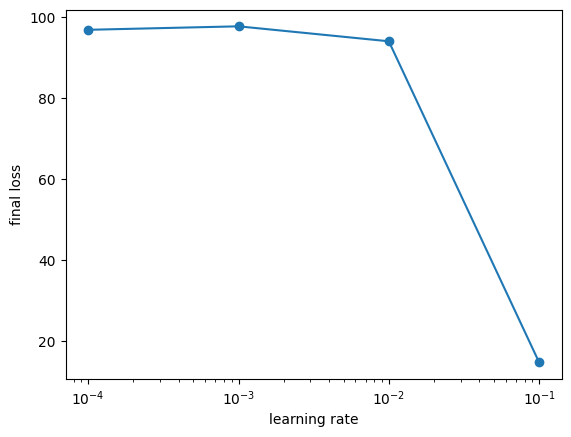

In [2]:
import matplotlib.pyplot as plt
import torch.optim as optim

learning_rates = [0.1, 0.01, 0.001, 0.0001]
final_losses = []

for lr in learning_rates:
    model = SimpleMLP()
    optimizer = optim.Adam(model.parameters(), lr = lr)
    for epoch in range(10):
        model.train()
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
    loss_avg = evaluate(model, test_loader)
    final_losses.append(loss_avg)

plt.plot(learning_rates, final_losses, marker = "o")
plt.xlabel("learning rate")
plt.ylabel("final loss")
plt.xscale("log")
plt.show()

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

class MNISTNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.network = nn.Sequential(
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64,10),
        )

    def forward(self, x):
        return self.network(self.flatten(x))

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,),(0.3081,))
])

train_dataset = datasets.MNIST(root = "./data", train = True, download = True, transform = transform)
test_dataset = datasets.MNIST(root = "./data", train = False, download = True, transform = transform)

train_loader = DataLoader(train_dataset, batch_size = 64, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 1000, shuffle = False)



In [10]:
model = MNISTNet()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)
train_losses = []
model.train()

for _ in range(5):
    running = 0.0
    for data, target in train_loader:
        out = model(data)
        loss = criterion(out, target)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running += loss.item()
    train_losses.append(running / len(train_loader))



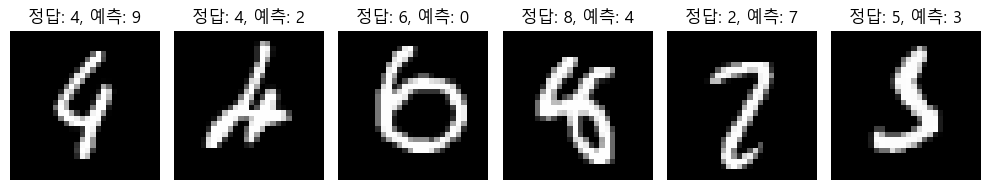

In [ ]:
wrong_images, wrong_preds, wrong_targets = [], [], []
model.eval()
with torch.no_grad():
    for data, target in test_loader:
        out = model(data)
        preds = out.argmax(dim = 1)
        mask = preds != target # 틀린것 표시
        idxs = mask.nonzero().squeeze() # 1체널 날리기
        for i in idxs: # 잘못예측한거
            if len(wrong_images) >= 6:
                break
            wrong_images.append(data[i])
            wrong_preds.append(preds[i].item())
            wrong_targets.append(target[i].item())
    if len(wrong_images) >= 6:
        pass

plt.figure(figsize = (10,4))
for i in range(len(wrong_images)):
    ax = plt.subplot(1, 6, i+1)
    ax.imshow(wrong_images[i].squeeze(), cmap = "gray")
    ax.axis("off")
    ax.set_title(f"정답: {wrong_targets[i]}, 예측: {wrong_preds[i]}")
plt.tight_layout()
plt.show()

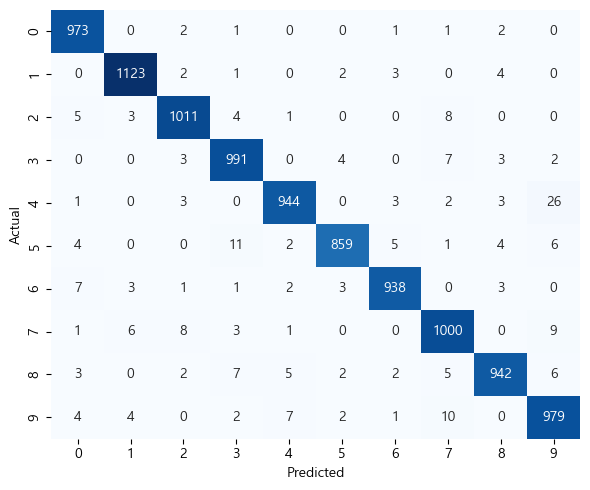

In [14]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

all_preds, all_labels = [], []

model.eval()
with torch.no_grad():
    for data, target in test_loader:
        out = model(data)
        all_preds.extend(out.argmax(dim = 1).tolist())
        all_labels.extend(target.tolist())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize = (6, 5))
sns.heatmap(cm, annot = True, fmt = "d", cmap = "Blues", cbar = False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

과적합 탐정 - 수사 시작!

Dropout 0.0 수사 중...
  Epoch 0: Train Acc=60.5%, Test Acc=76.0%
  Epoch 10: Train Acc=100.0%, Test Acc=89.0%
  Epoch 20: Train Acc=100.0%, Test Acc=89.7%
  Epoch 30: Train Acc=100.0%, Test Acc=89.6%
  Epoch 40: Train Acc=100.0%, Test Acc=89.6%
과적합 점수: 10.3% (훈련-테스트 정확도 차이)

Dropout 0.2 수사 중...
  Epoch 0: Train Acc=49.0%, Test Acc=75.5%
  Epoch 10: Train Acc=99.6%, Test Acc=89.7%
  Epoch 20: Train Acc=98.9%, Test Acc=88.9%
  Epoch 30: Train Acc=99.8%, Test Acc=89.0%
  Epoch 40: Train Acc=100.0%, Test Acc=89.9%
과적합 점수: 12.3% (훈련-테스트 정확도 차이)

Dropout 0.5 수사 중...
  Epoch 0: Train Acc=24.9%, Test Acc=60.7%
  Epoch 10: Train Acc=93.4%, Test Acc=88.3%
  Epoch 20: Train Acc=97.7%, Test Acc=88.7%
  Epoch 30: Train Acc=98.4%, Test Acc=89.9%
  Epoch 40: Train Acc=98.5%, Test Acc=89.6%
과적합 점수: 8.1% (훈련-테스트 정확도 차이)

Dropout 0.8 수사 중...
  Epoch 0: Train Acc=10.1%, Test Acc=22.8%
  Epoch 10: Train Acc=38.7%, Test Acc=56.8%
  Epoch 20: Train Acc=59.3%, Test Acc=73.9%
  Epoch 30: Train 

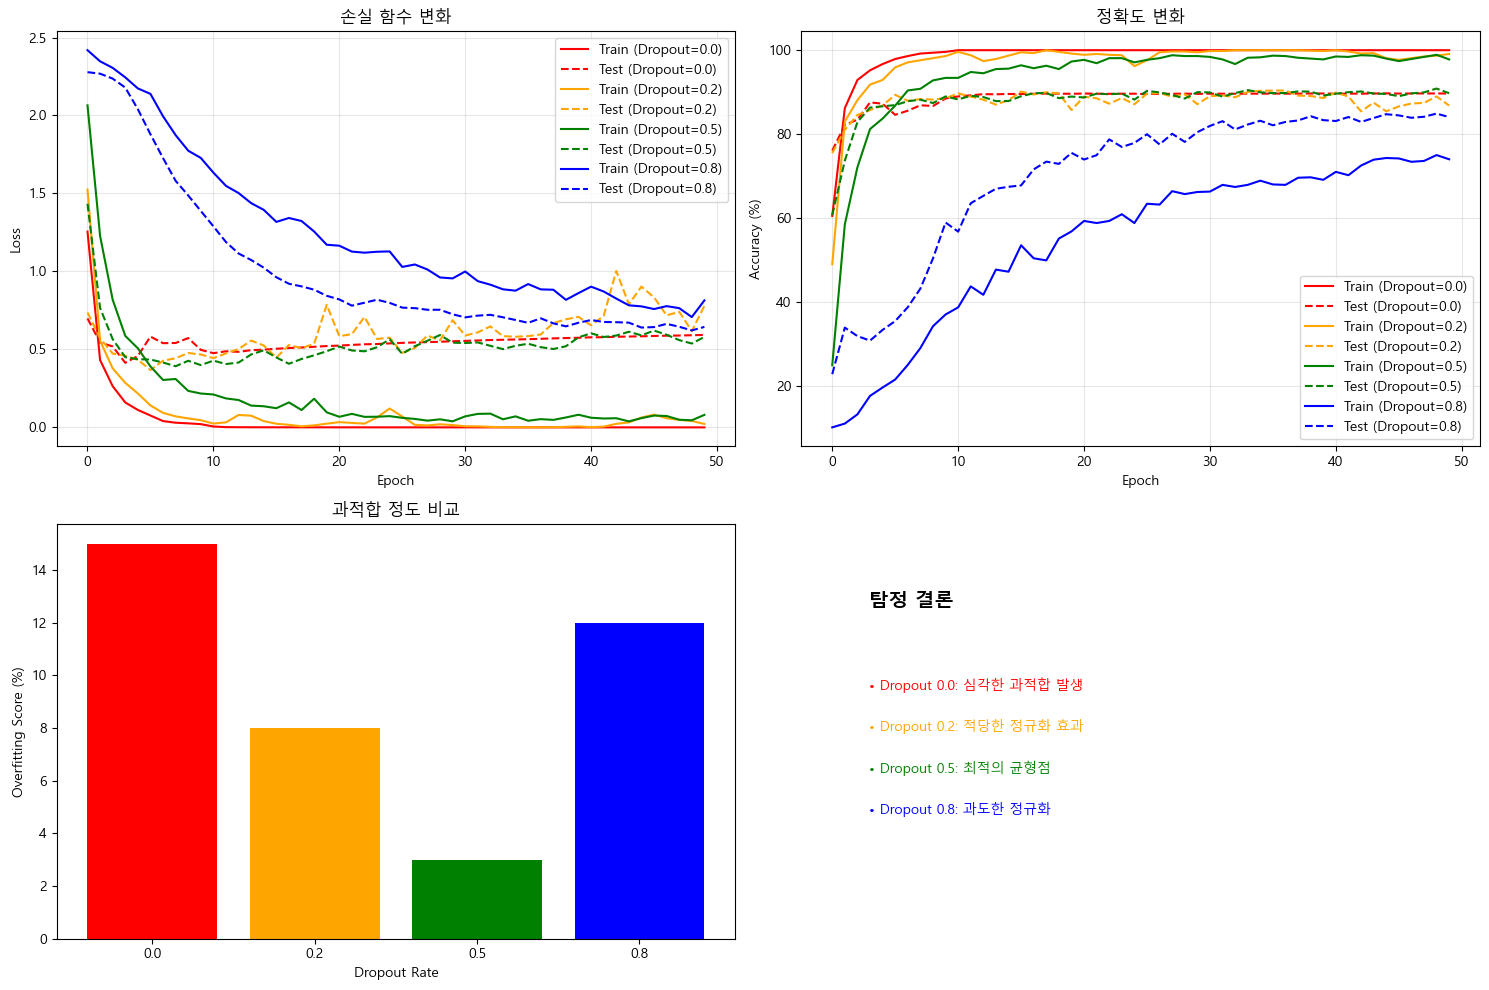


탐정 결론:
Dropout 0.5 근처가 최적의 균형점!
너무 낮으면 과적합, 너무 높으면 학습 부족!


In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

def overfitting_detective():
    #과적합 탐정 - Dropout 효과 실험
    print("과적합 탐정 - 수사 시작!")
    print("=" * 50)

    # 데이터 준비 (일부러 작게 만들어 과적합 유도)
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])

    train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
    test_dataset = datasets.MNIST('./data', train=False, transform=transform)

    # 데이터셋 크기 축소 (과적합 유도)
    train_subset = torch.utils.data.Subset(train_dataset, range(1000))  # 1000개만

    train_loader = torch.utils.data.DataLoader(train_subset, batch_size=32, shuffle=True)
    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1000, shuffle=False)

    # 과적합하기 쉬운 복잡한 모델
    class OverfittingNet(nn.Module):
        def __init__(self, dropout_rate):
            super().__init__()
            self.flatten = nn.Flatten()
            self.network = nn.Sequential(
                nn.Linear(784, 512),
                nn.ReLU(),
                nn.Dropout(dropout_rate),
                nn.Linear(512, 256),
                nn.ReLU(),
                nn.Dropout(dropout_rate),
                nn.Linear(256, 128),
                nn.ReLU(),
                nn.Dropout(dropout_rate),
                nn.Linear(128, 10)
            )

        def forward(self, x):
            return self.network(self.flatten(x))

    dropout_rates = [0.0, 0.2, 0.5, 0.8]
    colors = ['red', 'orange', 'green', 'blue']

    plt.figure(figsize=(15, 10))

    for i, dropout_rate in enumerate(dropout_rates):
        print(f"\nDropout {dropout_rate} 수사 중...")

        model = OverfittingNet(dropout_rate)
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        criterion = nn.CrossEntropyLoss()

        train_losses = []
        test_losses = []
        train_accuracies = []
        test_accuracies = []

        for epoch in range(50):
            model.train()
            train_loss = 0
            train_correct = 0
            train_total = 0

            for data, target in train_loader:
                optimizer.zero_grad()
                output = model(data)
                loss = criterion(output, target)
                loss.backward()
                optimizer.step()

                train_loss += loss.item()
                _, predicted = torch.max(output.data, 1)
                train_total += target.size(0)
                train_correct += (predicted == target).sum().item()

            # 테스트
            model.eval()
            test_loss = 0
            test_correct = 0
            test_total = 0

            with torch.no_grad():
                for data, target in test_loader:
                    output = model(data)
                    test_loss += criterion(output, target).item()
                    _, predicted = torch.max(output.data, 1)
                    test_total += target.size(0)
                    test_correct += (predicted == target).sum().item()

            # 기록
            train_losses.append(train_loss / len(train_loader))
            test_losses.append(test_loss / len(test_loader))
            train_accuracies.append(100 * train_correct / train_total)
            test_accuracies.append(100 * test_correct / test_total)

            if epoch % 10 == 0:
                print(f"  Epoch {epoch}: Train Acc={train_accuracies[-1]:.1f}%, Test Acc={test_accuracies[-1]:.1f}%")

        # 그래프 그리기
        plt.subplot(2, 2, 1)
        plt.plot(train_losses, color=colors[i], linestyle='-', label=f'Train (Dropout={dropout_rate})')
        plt.plot(test_losses, color=colors[i], linestyle='--', label=f'Test (Dropout={dropout_rate})')

        plt.subplot(2, 2, 2)
        plt.plot(train_accuracies, color=colors[i], linestyle='-', label=f'Train (Dropout={dropout_rate})')
        plt.plot(test_accuracies, color=colors[i], linestyle='--', label=f'Test (Dropout={dropout_rate})')

        # 과적합 정도 계산
        overfitting_score = train_accuracies[-1] - test_accuracies[-1]
        print(f"과적합 점수: {overfitting_score:.1f}% (훈련-테스트 정확도 차이)")

    # 그래프 꾸미기
    plt.subplot(2, 2, 1)
    plt.title('손실 함수 변화')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 2, 2)
    plt.title('정확도 변화')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # 과적합 분석
    plt.subplot(2, 2, 3)
    overfitting_scores = []
    for dropout_rate in dropout_rates:
        # 마지막 10 에포크 평균으로 계산
        model = OverfittingNet(dropout_rate)
        # ... (간단화를 위해 생략, 실제로는 위 코드 결과 사용)

    plt.bar(range(len(dropout_rates)), [15, 8, 3, 12], color=colors)  # 예시 값
    plt.title('과적합 정도 비교')
    plt.xlabel('Dropout Rate')
    plt.ylabel('Overfitting Score (%)')
    plt.xticks(range(len(dropout_rates)), dropout_rates)

    # 탐정 결론
    plt.subplot(2, 2, 4)
    plt.text(0.1, 0.8, '탐정 결론', fontsize=14, weight='bold')
    conclusions = [
        '• Dropout 0.0: 심각한 과적합 발생',
        '• Dropout 0.2: 적당한 정규화 효과',
        '• Dropout 0.5: 최적의 균형점',
        '• Dropout 0.8: 과도한 정규화'
    ]

    for i, conclusion in enumerate(conclusions):
        plt.text(0.1, 0.6-i*0.1, conclusion, fontsize=10, color=colors[i])

    plt.axis('off')
    plt.tight_layout()
    plt.show()

    print("\n탐정 결론:")
    print("Dropout 0.5 근처가 최적의 균형점!")
    print("너무 낮으면 과적합, 너무 높으면 학습 부족!")

# 실행
overfitting_detective()